In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\Collage\self\New folder\Project\CSV_file\pipeline_sensor_data_1M.csv")

print(df.shape)
df.head()

(200000, 6)


,timestamp,zone,flow,pressure,acoustic,anomaly
0,2026-03-05 21:49:17.995908,Nemani Godown,101.220417,55.040061,24.205546,0
1,2026-03-05 21:49:18.995908,Aleem Nagar,92.791317,48.743370,23.355619,0
2,2026-03-05 21:49:19.995908,Bhaji Bazar,152.717158,39.006599,42.554471,1
3,2026-03-05 21:49:20.995908,Ziri,104.652380,59.225662,29.012009,0
4,2026-03-05 21:49:21.995908,VMV Area,131.494053,29.473056,41.178725,1


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   timestamp  200000 non-null  object 
 1   zone       200000 non-null  object 
 2   flow       200000 non-null  float64
 3   pressure   200000 non-null  float64
 4   acoustic   200000 non-null  float64
 5   anomaly    200000 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 9.2+ MB


,flow,pressure,acoustic,anomaly
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,101.745071,53.903040,25.943237,0.049760
std,9.341453,5.667618,4.669834,0.217449
min,77.584963,23.414120,15.382562,0.000000
25%,96.838346,52.581227,23.739627,0.000000
50%,100.339049,54.806017,25.133393,0.000000
75%,104.004313,56.899735,26.613214,0.000000
max,173.552602,68.498348,61.619448,1.000000


In [8]:
df.isnull().sum()


timestamp    0
zone         0
flow         0
pressure     0
acoustic     0
anomaly      0
dtype: int64

In [9]:
df = df.drop_duplicates()

In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [11]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [13]:
df = df[df["flow"] > 0]
df = df[df["pressure"] > 0]
df = df[df["acoustic"] > 0]

In [14]:
Q1 = df[["flow","pressure","acoustic"]].quantile(0.25)
Q3 = df[["flow","pressure","acoustic"]].quantile(0.75)

IQR = Q3 - Q1

df = df[~((df[["flow","pressure","acoustic"]] < (Q1 - 1.5 * IQR)) |
          (df[["flow","pressure","acoustic"]] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [15]:
df = pd.get_dummies(df, columns=["zone"], drop_first=True)

In [16]:
df.reset_index(drop=True, inplace=True)

In [18]:
df.to_csv(r"D:\Collage\self\New folder\Project\CSV_file\pipeline_sensor_data_1M.csv", index=False)

In [19]:
#Exploratory Data Analysis


In [20]:
# Check anomaly distribution
df["anomaly"].value_counts()


anomaly
0    187624
Name: count, dtype: int64

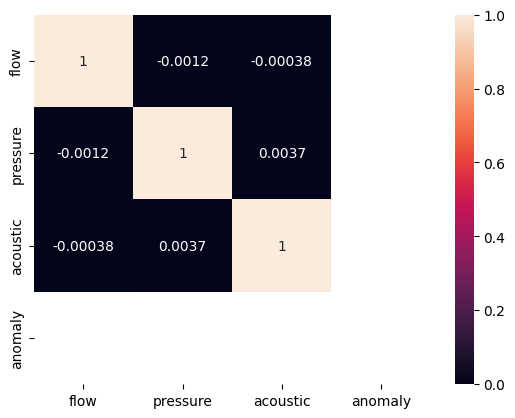

In [22]:
# Check correlation
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[["flow","pressure","acoustic","anomaly"]].corr(), annot=True)
plt.show()